# Gaussian Process Emulator for CMB

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import GPy

## Example from Scikit-learn
https://scikit-learn.org/stable/modules/gaussian_process.html

In [2]:
X = np.linspace(start=0, stop=10, num=1_000).reshape(-1, 1)
y1 = np.squeeze(X * np.sin(X))
y2 = np.squeeze(X * np.cos(X))
y = np.column_stack((y1, y2))

In [3]:
y.shape

(1000, 2)

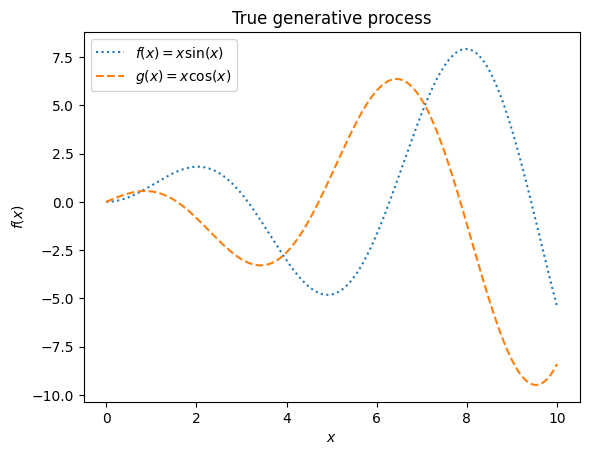

In [4]:
plt.plot(X, y1, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.plot(X, y2, label=r"$g(x) = x \cos(x)$", linestyle="--")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("True generative process")

In [5]:
rng = np.random.RandomState(1)
training_indices = rng.choice(np.arange(1000), size=6, replace=False)
X_train, y_train = X[training_indices], y[training_indices]

In [6]:
y_train

array([[-4.74492726,  1.80056999],
       [ 7.73514288, -2.68588726],
       [-4.44491693, -0.84500632],
       [-1.90051689, -3.15556034],
       [ 1.5957965 , -1.82251583],
       [ 1.16380401, -9.22618706]])

In [9]:
kernel = GPy.kern.RBF(input_dim=1, variance=1., lengthscale=1.)
gaussian_process = GPy.models.GPRegression(X_train, y_train, kernel)
gaussian_process.optimize_restarts(num_restarts=10)

Optimization restart 1/10, f = 29.868888224578534
Optimization restart 2/10, f = 29.86888817168436
Optimization restart 3/10, f = 29.868891425723444
Optimization restart 4/10, f = 29.86888814076935
Optimization restart 5/10, f = 29.868888602833405
Optimization restart 6/10, f = 29.868888357032702
Optimization restart 7/10, f = 29.868927100575746
Optimization restart 8/10, f = 29.868888634723977
Optimization restart 9/10, f = 29.868888163137814
Optimization restart 10/10, f = 29.868905099828968


['dataplot', 'gpmean', 'gpconfidence']


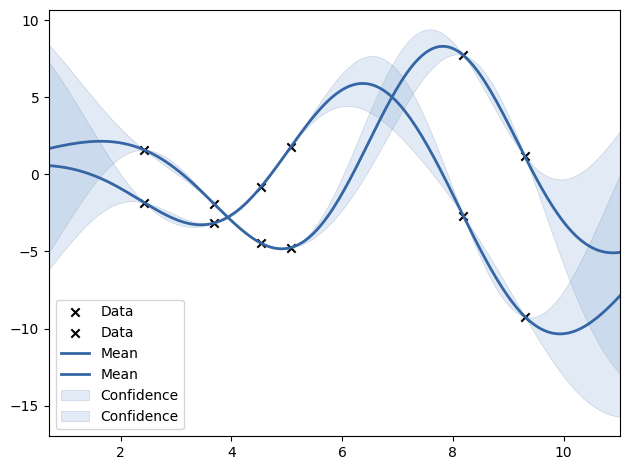

In [ ]:
fig = gaussian_process.plot()
X_input = np.array([6, 6])
gaussian_process.predict(np.array([X_input]))

## CMB Dataset

In [ ]:
# Load data
NUM_TRAIN_SAMPLES = 9864
NUM_TEST_SAMPLES = 976
NUM_ELL = 2999

ell = np.arange(2, 3001)
factor = ell*(ell+1)/(2*np.pi)
train_cosmologies = np.loadtxt("../data/train/cosmologies.txt", max_rows=NUM_TRAIN_SAMPLES)
test_cosmologies = np.loadtxt("../data/test/cosmologies.txt", max_rows=NUM_TEST_SAMPLES)
train_cls = np.zeros((NUM_TRAIN_SAMPLES, NUM_ELL))
test_cls  = np.zeros((NUM_TRAIN_SAMPLES, NUM_ELL))

for i in range(1, NUM_TRAIN_SAMPLES+1):
    dl_tt, dl_te, dl_ee = np.loadtxt(f"../data/train/cl_{i}.txt", unpack=True)
    train_cls[i-1] = dl_tt/factor

for i in range(1, NUM_TEST_SAMPLES+1):
    cl_tt, cl_te, cl_ee = np.loadtxt(f"../data/test/cl_{i}.txt", unpack=True)
    test_cls[i-1] = dl_tt/factor


 /var/folders/pm/h623358x68n6tdb7xj7s_9qr0000gn/T/ipykernel_2433/960454047.py:8: UserWarning:Input line 1 contained no data and will not be counted towards `max_rows=9864`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
 /var/folders/pm/h623358x68n6tdb7xj7s_9qr0000gn/T/ipykernel_2433/960454047.py:9: UserWarning:Input line 1 contained no data and will not be counted towards `max_rows=976`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ig

In [27]:
# Thinning training sample
partial_indices = np.random.choice(np.arange(NUM_TRAIN_SAMPLES), size=2000)
train_cosmologies_partial = train_cosmologies[partial_indices]
train_cls_partial         = train_cls[partial_indices]

In [28]:
# Scale by As
As1e10 = np.exp(train_cosmologies_partial[:, 3])
for i, cl in enumerate(train_cls_partial):
    train_cls_partial[i]  = cl/As1e10[i]
train_cosmologies_partial = np.delete(train_cosmologies_partial, 3, axis=1) # No need for As in inputs

# Take the log
train_logcls_partial = np.log(train_cls_partial)

Text(0.5, 1.0, 'Training data')

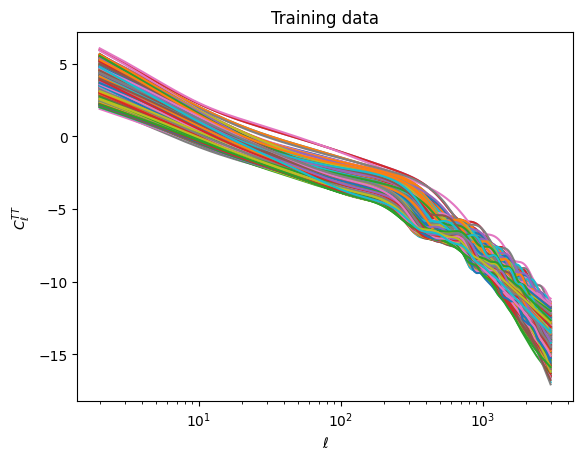

In [31]:
for logcl in train_logcls_partial:
    plt.semilogx(ell, logcl)
plt.xlabel("$\\ell$")
plt.ylabel("$C_\\ell^{TT}$")
plt.title("Training data")

In [32]:
# Scalers for inputs and outputs
scaler_cosmo = StandardScaler()
scaled_cosmos = scaler_cosmo.fit_transform(train_cosmologies_partial)
scaler_logcls = StandardScaler()
scaled_logcls = scaler_logcls.fit_transform(train_logcls_partial)

In [106]:
# PCA
num_pcs = 10
pca = PCA(n_components=num_pcs, svd_solver='full')
train_pcs = pca.fit_transform(scaler_logcls.transform(train_logcls_partial))
scaler_pcs = StandardScaler()
scaled_pcs = scaler_pcs.fit_transform(train_pcs)

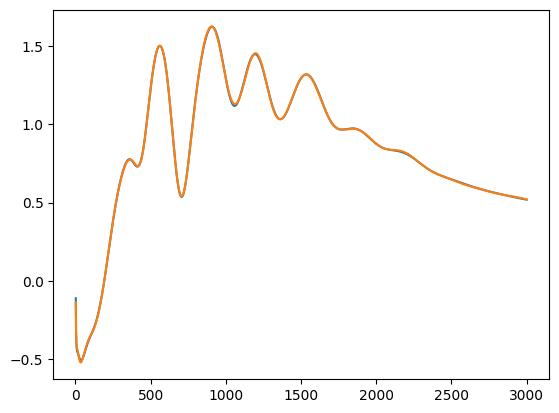

In [68]:
# Test PCA reconstruction
reconstructed_logcls = pca.inverse_transform(train_pcs)
for train_logcl, reconstructed_logcl in zip(train_logcls_partial, reconstructed_logcls):
    plt.plot(ell, scaler_logcls.transform([train_logcl])[0])
    plt.plot(ell, reconstructed_logcl)
    break

In [ ]:
X_train = scaled_cosmos
models = []
for i in range(num_pcs):
    y_train = np.array([[scaled_pcs[j, i]] for j in range(2000)])
    kernel = GPy.kern.Matern52(len(X_train[0]), ARD=True)
    gaussian_process = GPy.models.GPRegression(X_train, y_train, kernel)
    print(f"Training PC {i+1}...")
    gaussian_process.optimize_restarts(num_restarts=3)
    models.append(gaussian_process)

Optimization restart 1/3, f = 150.03638181958502
Optimization restart 2/3, f = 150.03638155729004


 /Users/joao/miniconda3/envs/hackathon/lib/python3.11/site-packages/GPy/kern/src/stationary.py:166: RuntimeWarning:overflow encountered in divide
 /Users/joao/miniconda3/envs/hackathon/lib/python3.11/site-packages/GPy/kern/src/stationary.py:137: RuntimeWarning:overflow encountered in square
 /Users/joao/miniconda3/envs/hackathon/lib/python3.11/site-packages/GPy/kern/src/stationary.py:138: RuntimeWarning:invalid value encountered in add
 /Users/joao/miniconda3/envs/hackathon/lib/python3.11/site-packages/GPy/kern/src/stationary.py:586: RuntimeWarning:invalid value encountered in multiply


Optimization restart 3/3, f = 152.46155126278552
Optimization restart 1/3, f = 1508.5173701393128
Optimization restart 2/3, f = 1508.5173121550238
Optimization restart 3/3, f = 1508.5173286218715
Optimization restart 1/3, f = 924.0087621552988
Optimization restart 2/3, f = 924.0087598954103
Optimization restart 3/3, f = 924.0087603441724
Optimization restart 1/3, f = 1308.2363074836258
Optimization restart 2/3, f = 1308.2363078979379
Optimization restart 3/3, f = 1308.2363076469892
Optimization restart 1/3, f = 1255.5733858550748
Optimization restart 2/3, f = 1255.573386834336
Optimization restart 3/3, f = 1255.5733860266837
Optimization restart 1/3, f = 1054.0820084103598
Optimization restart 2/3, f = 1054.08194634259
Optimization restart 3/3, f = 1054.0819466786972
Optimization restart 1/3, f = -590.4433522891154
Optimization restart 2/3, f = 477.0042953311995
Optimization restart 3/3, f = -590.443356950457
Optimization restart 1/3, f = 1485.3869496708662
Optimization restart 2/3, f 

 /Users/joao/miniconda3/envs/hackathon/lib/python3.11/site-packages/GPy/kern/src/stationary.py:243: RuntimeWarning:invalid value encountered in divide


Optimization restart 2/3, f = 637.2168016604805
Optimization restart 3/3, f = 1122.3943304130385
Optimization restart 1/3, f = 661.4953155408352
Optimization restart 2/3, f = 1085.3268276459753
Optimization restart 3/3, f = 1064.7165932724022
Optimization restart 1/3, f = 1066.947189288484
Optimization restart 2/3, f = 577.9645188854528
Optimization restart 3/3, f = 577.9641643407441
Optimization restart 1/3, f = 793.7315692252073
Optimization restart 2/3, f = 1077.8132405478887
Optimization restart 3/3, f = 1085.7106072825936
Optimization restart 1/3, f = 1106.4245364481226
Optimization restart 2/3, f = 1065.7724161281476
Optimization restart 3/3, f = 1065.7723120203298
Optimization restart 1/3, f = 1109.7393217735748
Optimization restart 2/3, f = 1061.1837830115917
Optimization restart 3/3, f = 863.7088339937059
Optimization restart 1/3, f = 1066.4162894739388
Optimization restart 2/3, f = 1065.7623167464546
Optimization restart 3/3, f = 884.8138561750275
Optimization restart 1/3, f 

In [113]:
models[0]

In [127]:
def predict(models, x):
    As1e10_input = np.exp(x[3])
    x_input = scaler_cosmo.transform([[x[0], x[1], x[2], x[4], x[5]]])
    scaled_pcs_pred = []
    for i in range(num_pcs):
        scaled_pc_pred, pred_std = models[i][0].predict(x_input)
        scaled_pcs_pred.append(scaled_pc_pred[0, 0])
    pred_pcs = scaler_pcs.inverse_transform([scaled_pcs_pred])
    scaled_logcl = pca.inverse_transform(pred_pcs)
    logcl = scaler_logcls.inverse_transform(scaled_logcl)
    return As1e10_input*np.exp(logcl)[0]

Text(0, 0.5, 'Relative error on $C^{TT}_\\ell$')

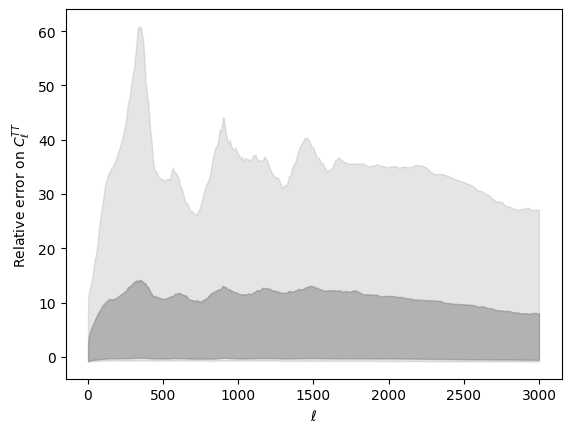

In [128]:
errors = []
for i in range(NUM_TEST_SAMPLES):
    truth = test_cls[i]/test_cosmologies[i, 3]
    pred = predict(models, test_cosmologies[i])
    err = (pred - truth)/truth
    errors.append(err)
errors = np.array(errors)
lower = np.percentile(errors, 2.5, axis=0)
upper = np.percentile(errors, 97.5, axis=0)
plt.fill_between(ell, lower, upper, alpha=0.2, color="gray")
lower = np.percentile(errors, 50-68//2, axis=0)
upper = np.percentile(errors, 50+68//2, axis=0)
plt.fill_between(ell, lower, upper, alpha=0.5, color="gray")
plt.xlabel("$\\ell$")
plt.ylabel("Relative error on $C^{TT}_\\ell$")

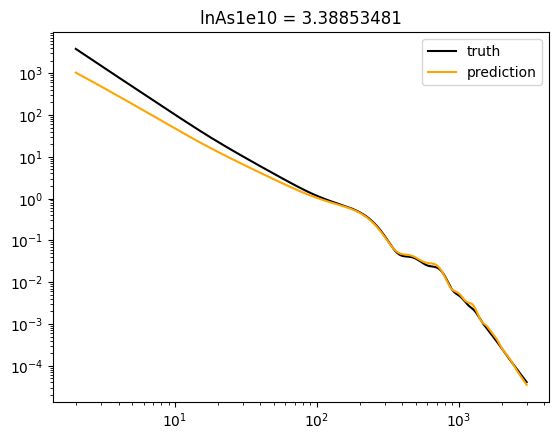

In [140]:
i = 1
plt.title(f"lnAs1e10 = {test_cosmologies[i, 3]}")
truth = test_cls[i]
pred = predict(models, test_cosmologies[i])
plt.loglog(ell, truth, color="black", label="truth")
plt.loglog(ell, pred, color="orange", label="prediction")
plt.legend()

In [139]:
models[0][0]

GP_regression.,value,constraints,priors
sum.Mat52.variance,3425.729644239693,+ve,
sum.Mat52.lengthscale,"(5,)",+ve,
sum.white.variance,5.562684646268137e-309,+ve,
Gaussian_noise.variance,0.05694361839679213,+ve,
